# 🤖 Chapter 2: Introduction to Machine Learning

---

## What Is Machine Learning?

Machine learning is a way for computers to learn patterns from data and use those patterns to make predictions.

In regular programming, a person writes the rules. In machine learning, the computer learns the rules from examples — just like Netflix predicts what you'll watch next.

No advanced math required. Just curiosity and Python! 

---

### 🎯 Learning Goals

By the end of this chapter you will be able to:

| # | Goal |
|---|------|
| 1 | Explain what machine learning is in your own words |
| 2 | Tell the difference between ML and regular programming |
| 3 | Identify **features** and **labels** in a dataset |
| 4 | Build and train a simple prediction model in Python |
| 5 | Visualize data and model predictions with a chart |
| 6 | Reflect on what a model can and cannot do |

---
## ⚙️ Setup — Import Required Libraries

Run the cell below once to import the libraries used in this chapter.

In [25]:
# importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

---
## 2.1 Warm-Up — Think About It First 

Before we dive into code, let's think about what you already know.

Answer the questions below in the cell provided — just write your thoughts, there are no wrong answers!

> 🏋️ **Warm-Up Questions:** Answer in your own words below.
>
> 1. Where have you seen a computer make a prediction (machine learning in everyday life)? 
> 2. What do you think a computer needs in order to make a good prediction?
> 3. What's the difference between a computer *following rules* and a computer *learning from examples*?

**✏️ Your answers here:**

1. 
2. 
3. 

---
## 2.2 Machine Learning vs. Regular Programming 

Most of what you wrote in Chapter 1 was **regular programming** — you told the computer exactly what to do using rules.

**Machine learning is different.** Instead of writing rules, you show the computer lots of examples and let it figure out the pattern on its own.

```
┌─────────────────────────────────────────────────────────┐
│              REGULAR PROGRAMMING                        │
│   You write rules → Computer follows them               │
│                                                         │
│   if score >= 90: print("A")                            │
│   if score >= 80: print("B")  ← YOU wrote these rules  │
└─────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────┐
│              MACHINE LEARNING                           │
│   You give examples → Computer learns the rules         │
│                                                         │
│   scores = [55, 70, 85, 92...]  ← you give examples    │
│   model.fit(scores)             ← computer finds rules  │
└─────────────────────────────────────────────────────────┘
```

### Real-world examples:

| App | Regular Programming | Machine Learning |
|-----|--------------------|-----------------|
| Spotify | Play song when pressed | *Predict* what song you'll like next |
| Instagram | Show posts in order | *Predict* which posts to show you |
| Gmail | Send email when clicked | *Predict* if an email is spam |
| iPhone | Unlock with passcode | *Predict* if the face matches yours |

> 🏋️ **Practice 1:** For each example below, decide if it's regular programming or machine learning. Write your answers in the markdown cell below.
>
> - A calculator that adds two numbers
> - Netflix recommending a show you might like
> - A traffic light that turns green every 60 seconds
> - Google Translate converting English to Spanish
> - A game that pauses when you press Escape

**✏️ Your answers here:**

- Calculator: 
- Netflix: 
- Traffic light: 
- Google Translate: 
- Escape key: 

---
## 2.3 Our First Dataset 📊

Every machine learning model needs **data** to learn from.

We'll start with a small, simple dataset: how many hours students studied vs. the quiz score they got. Our goal is to teach a model to **predict a student's quiz score based on how many hours they studied**.

### Key Vocabulary

| Term | Definition | In our dataset |
|------|-----------|----------------|
| **Feature** | The input — what we use to make a prediction | `study_hours` |
| **Label** | The output — what we're trying to predict | `quiz_score` |
| **Training data** | The examples we use to teach the model | All 8 rows |

In [26]:
# our dataset: study hours → quiz scores
data = pd.DataFrame({
    'study_hours': [1, 2, 3, 4, 5, 6, 7, 8],
    'quiz_score':  [55, 60, 63, 68, 72, 78, 84, 90]
})

print("Our dataset:")
data

Our dataset:


,study_hours,quiz_score
0,1,55
1,2,60
2,3,63
3,4,68
4,5,72
5,6,78
6,7,84
7,8,90


In [27]:
# separate the feature (X) and the label (y)
# X = what we know  →  y = what we want to predict

X = data[['study_hours']]  # feature (double brackets = DataFrame)
y = data['quiz_score']     # label   (single bracket = Series)

print("feature (X) — study hours:")
print(X.head())

print("\nlabel (y) — quiz scores:")
print(y.head())

feature (X) — study hours:
   study_hours
0            1
1            2
2            3
3            4
4            5

label (y) — quiz scores:
0    55
1    60
2    63
3    68
4    72
Name: quiz_score, dtype: int64


> 🏋️ **Practice 2:** Look at the dataset above and answer:
> 1. How many students are in the dataset?
> 2. What is the highest quiz score? How many hours did that student study?
> 3. Can you spot the pattern just by looking at the numbers?

**✏️ Your answers here:**

1. 
2. 
3. 

---
## 2.4 Visualize the Data 📈

Before building a model, it's always a good idea to **look at the data first**. A chart can reveal patterns that are hard to see in a table of numbers.

We'll use a **scatter plot** (each dot represents one student) to see the relationship between study time and quiz score.

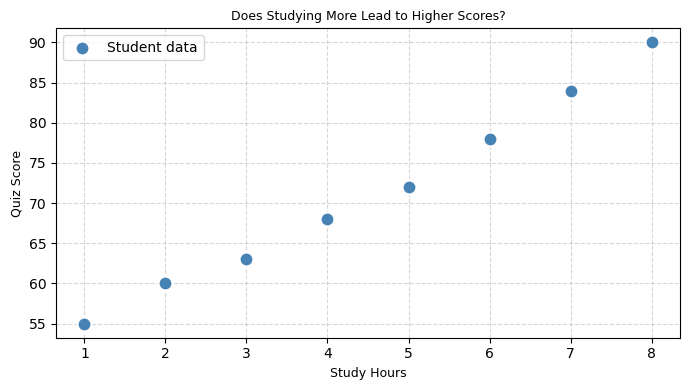

In [28]:
plt.figure(figsize=(7, 4))

plt.scatter(
    data['study_hours'],
    data['quiz_score'],
    color='steelblue',
    s=100,           # dot size
    edgecolors='white',
    linewidths=1.5,
    zorder=3,
    label='Student data'
)

plt.xlabel('Study Hours', fontsize=9)
plt.ylabel('Quiz Score', fontsize=9)
plt.title('Does Studying More Lead to Higher Scores?', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

> 🏋️ **Practice 3 — Think & Respond:**
> 1. What pattern do you notice in the scatter plot?
> 2. Does the relationship look like a straight line, a curve, or random?
> 3. Based on the chart, if a student studies for 6.5 hours, what score would *you* predict?

**✏️ Your answers here:**

1. 
2. 
3. 

---
## 2.5 Build Your First ML Model 🏗️

A model is a rule the computer learns from data so it can make predictions.

We'll use **Linear Regression** — one of the simplest and most widely used ML models. It works by finding the best straight line through the data points.

Think of it like this: you're drawing a line of best fit through a scatter plot (you may have done this in Algebra class!). The model finds the *perfect* line automatically.

```
Quiz
Score
  90 |          ●  ← real data point
  80 |       ●  /
  70 |    ●  / ← model's prediction line
  60 | ●  /
  50 |/
     └──────────── Study Hours
```

Training the model = finding the best position for that line.

In [29]:
# step 1: create the model
model = LinearRegression()

# step 2: train it — show it the data so it can learn the pattern
model.fit(X, y)

print("Model trained!")
print(f"\nWhat the model learned:")
print(f"  • For every extra study hour, score goes up by ~{model.coef_[0]:.1f} points")
print(f"  • Starting score (0 hours studied): ~{model.intercept_:.1f}")

Model trained!

What the model learned:
  • For every extra study hour, score goes up by ~4.9 points
  • Starting score (0 hours studied): ~49.1


> 🏋️ **Practice 4:** Look at what the model learned above.
> 1. If a student studies 1 extra hour, by how many points does their score increase?
> 2. Does that number match what you see in the data table from Section 2.3?
> 3. What does the "starting score" tell us? Does it make sense?

**✏️ Your answers here:**

1. 
2. 
3. 

---
## 2.6 Make Predictions 

Now that the model is trained, we can ask it to predict scores for study hours it has **never seen before**. This is the whole point of machine learning — learning from past data to predict future outcomes!

In [30]:
# ask the model to predict for new study hour values
new_hours = pd.DataFrame({'study_hours': [2.5, 5.5, 9, 0.5, 10]})

predictions = model.predict(new_hours)

# display results nicely
results = new_hours.copy()
results['predicted_score'] = predictions.round(1)

print("Model Predictions:")
results

Model Predictions:


,study_hours,predicted_score
0,2.5,61.4
1,5.5,76.2
2,9.0,93.4
3,0.5,51.5
4,10.0,98.4


> 🏋️ **Practice 5:** 
> 1. Add **your own study hours** to the `new_hours` list and see what score the model predicts for you!
> 2. What happens if you predict for 0 hours? Does that make sense in real life?
> 3. What happens if you predict for 20 hours? Is that realistic?

In [31]:
# try your own values!
my_hours = pd.DataFrame({'study_hours': [3.5]})  # change this!
my_prediction = model.predict(my_hours)
print(f"If I study {my_hours['study_hours'][0]} hours, the model predicts a score of: {my_prediction[0]:.1f}")

If I study 3.5 hours, the model predicts a score of: 66.3


---
## 2.7 Visualize the Prediction Line 📉

Now let's plot both the **real data** and the **model's prediction line** on the same chart. This lets us see how well the model fits the data.

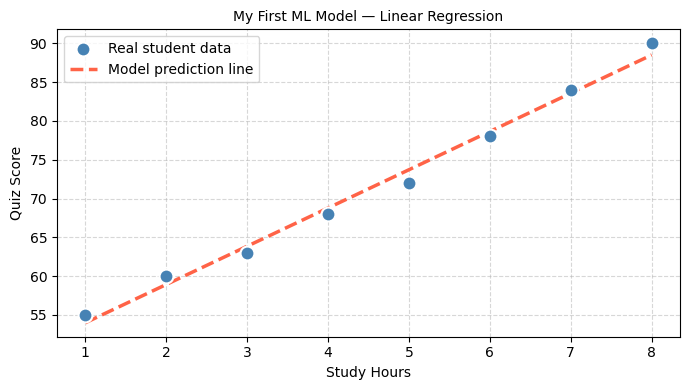

In [32]:
plt.figure(figsize=(7, 4))

# plot real data points
plt.scatter(
    data['study_hours'],
    data['quiz_score'],
    color='steelblue',
    s=100,
    edgecolors='white',
    linewidths=1.5,
    zorder=3,
    label='Real student data'
)

# plot the model's prediction line
plt.plot(
    data['study_hours'],
    model.predict(X),
    color='tomato',
    linewidth=2.5,
    linestyle='--',
    label='Model prediction line'
)

plt.xlabel('Study Hours', fontsize=10)
plt.ylabel('Quiz Score', fontsize=10)
plt.title('My First ML Model — Linear Regression', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> 🏋️ **Practice 6 — Analyze the Chart:**
> 1. Does the red line pass through every blue dot? Why or why not?
> 2. Where is the model's prediction *closest* to the real data? Where is it *furthest*?
> 3. If you had 100 students in the dataset instead of 8, do you think the line would be more or less accurate?

**✏️ Your answers here:**

1. 
2. 
3. 

---
## 2.8 Reflection — Limits of the Model 🤔

Our model is simple and it's not perfect. That's okay — even the most advanced ML models make mistakes.

Here are some reasons why a model might be wrong:

- **Too little data** — 8 students is not enough to represent all students
- **Missing features** — maybe sleep, stress, or difficulty of the quiz also matters
- **Wrong model type** — maybe the relationship isn't actually a straight line
- **Data doesn't represent the real world** — our data was made up!

> 🏋️ **Practice 7 — Reflection Questions:**
> 1. What was the **feature** in this notebook?
> 2. What was the **label**?
> 3. What did the model "learn" from the data?
> 4. Why might the model make mistakes in real life?
> 5. Name **two other features** that could help improve predictions of quiz scores.

**✏️ Your answers here:**

1. 
2. 
3. 
4. 
5. 

---
## 2.9 Extension Activity 🚀

Ready for a challenge? Try modifying the dataset and see how the model changes!

**Option A — Change the data:**
Edit the dataset below to use scores from your actual class (or make up new ones). Does the model still work?

**Option B — Add a second feature:**
Add a `sleep_hours` column to the dataset. Can you train a model that uses *both* study hours and sleep hours to predict a score?

**Option C — Make it personal:**
Survey your friends: how many hours did they study and what score did they get? Build a model from *real* data!

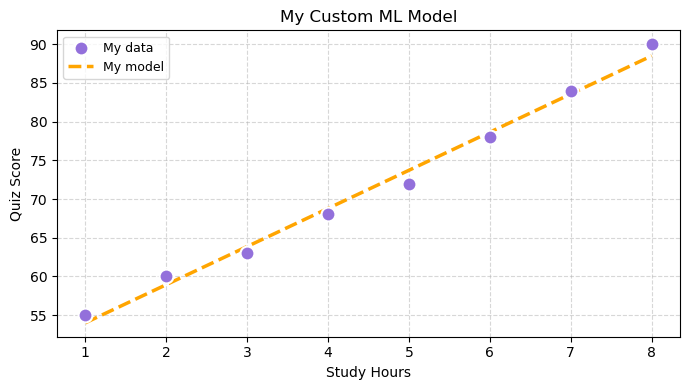

Score increase per study hour: 4.93 points


In [33]:
# option A: try changing the quiz scores below and re-run the model!
my_data = pd.DataFrame({
    'study_hours': [1, 2, 3, 4, 5, 6, 7, 8],
    'quiz_score':  [55, 60, 63, 68, 72, 78, 84, 90]  # ← change these!
})

X2 = my_data[['study_hours']]
y2 = my_data['quiz_score']

my_model = LinearRegression()
my_model.fit(X2, y2)

# plot the result
plt.figure(figsize=(7, 4))
plt.scatter(my_data['study_hours'], my_data['quiz_score'],
            color='mediumpurple', s=100, edgecolors='white',
            linewidths=1.5, zorder=3, label='My data')
plt.plot(my_data['study_hours'], my_model.predict(X2),
         color='orange', linewidth=2.5, linestyle='--', label='My model')
plt.xlabel('Study Hours', fontsize=10)
plt.ylabel('Quiz Score', fontsize=10)
plt.title('My Custom ML Model', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Score increase per study hour: {my_model.coef_[0]:.2f} points")

---
## ✏️ 2.10 Finish This Sentence

Complete the sentence below in your own words — no right or wrong answer!

**Machine learning is...**

*(Write your answer here)*

---
## 🎉 Chapter 2 Summary

Great work finishing Chapter 2! Here's everything you learned:

| Topic | Key Idea |
|-------|----------|
| Machine Learning | The computer learns patterns from examples instead of following hand-written rules |
| Feature | The input used to make a prediction (e.g. `study_hours`) |
| Label | The output we want to predict (e.g. `quiz_score`) |
| Training | Showing the model examples so it can learn the pattern (`model.fit`) |
| Predicting | Asking the model to guess outcomes for new data (`model.predict`) |
| Linear Regression | A model that fits a straight line through data points |
| Visualization | Plotting data and the prediction line to see how well the model fits |
| Model Limits | More data, more features, and the right model type = better predictions |

---

### 🏆 Chapter Challenge

Build a model that predicts a **movie rating** based on its **budget** (in millions). Use made-up data with at least 10 movies. Train the model, visualize it, and use it to predict the rating for a \$200M budget film.

Can you also try predicting using **two features** — budget AND runtime?

In [ ]:
# 🏆 Chapter Challenge — Movie Rating Predictor
# your code here!

movies = pd.DataFrame({
    'budget_millions': [10, 25, 50, 80, 100, 120, 150, 180, 200, 250],
    'rating':          [5.2, 6.0, 6.5, 7.1, 7.4, 7.8, 8.0, 8.2, 8.5, 8.7]
})

# your code: train a model, make predictions, and plot the results!
